# Notebook 05 — Linear Weights Explainer

Linear weights assign a run value to each offensive event based on how many runs it produces on average, given the base-out state when it occurs. The idea: a home run is worth more than a single, but how much more?

1. Assigns run values to BB, HBP, 1B, 2B, 3B, HR
2. Scales the result to look like OBP (~.320 league average) for interpretability
3. Converts to wRC+ (Weighted Runs Created Plus). A park- and league-adjusted version where 100 = average

This notebook walks through the full derivation using 2025 MLB data.

In [26]:
import os, sys, time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath(".."))

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)

DATA = os.path.join("..", "data")

## 1. Fetch detailed counting stats from MLB API

Our master table has PA, HR, BB, SO but we need **1B, 2B, 3B, HBP, SF** to compute wOBA from scratch. We'll pull these from the MLB Stats API for all hitters in our master table.

In [28]:
import requests

master = pd.read_parquet(os.path.join(DATA, "master_players.parquet"))
hitters = master[master["player_type"] == "hitter"].copy()
hitter_ids = hitters["mlbam_id"].tolist()

BASE_URL = "https://statsapi.mlb.com/api/v1"
all_rows = []

for i in range(0, len(hitter_ids), 100):
    batch = hitter_ids[i : i + 100]
    ids_str = ",".join(str(int(pid)) for pid in batch)
    time.sleep(0.5)
    resp = requests.get(
        f"{BASE_URL}/people",
        params={"personIds": ids_str,
                "hydrate": "stats(group=hitting,type=season,season=2025)"},
        timeout=30,
    )
    for p in resp.json().get("people", []):
        stats_list = p.get("stats", [])
        if not stats_list:
            continue
        for split in stats_list[0].get("splits", []):
            s = split.get("stat", {})
            pa = int(s.get("plateAppearances", 0))
            if pa < 50:
                continue
            h = int(s.get("hits", 0))
            doubles = int(s.get("doubles", 0))
            triples = int(s.get("triples", 0))
            hr = int(s.get("homeRuns", 0))
            singles = h - doubles - triples - hr
            all_rows.append({
                "mlbam_id": p["id"],
                "PA": pa,
                "AB": int(s.get("atBats", 0)),
                "H": h,
                "1B": singles,
                "2B": doubles,
                "3B": triples,
                "HR": hr,
                "BB": int(s.get("baseOnBalls", 0)),
                "IBB": int(s.get("intentionalWalks", 0)),
                "HBP": int(s.get("hitByPitch", 0)),
                "SF": int(s.get("sacFlies", 0)),
                "SB": int(s.get("stolenBases", 0)),
                "CS": int(s.get("caughtStealing", 0)),
            })

detail = pd.DataFrame(all_rows)
detail = detail.sort_values("PA", ascending=False).drop_duplicates(subset="mlbam_id").reset_index(drop=True)
print(f"Detailed stats for {len(detail)} hitters")
detail.head(5)

Detailed stats for 537 hitters


,mlbam_id,PA,AB,H,1B,2B,3B,HR,BB,IBB,HBP,SF,SB,CS
0,596019,732,644,172,106,35,0,31,65,2,16,7,31,6
1,646240,729,607,153,85,33,0,35,112,10,6,4,1,1
2,660271,727,611,172,83,25,9,55,109,20,3,2,20,6
3,656941,724,604,145,64,23,2,56,108,6,11,1,10,2
4,621566,724,624,170,98,41,2,29,91,2,4,5,1,0


## 2. The 2025 linear weights (wOBA constants)

FanGraphs publishes season-specific linear weights on their [Guts! page](https://www.fangraphs.com/guts.aspx?type=cn). These weights come from run expectancy matrices. the change in expected runs for each event, averaged across all base-out states.

The wOBA formula is:

$$
\text{wOBA} = \frac{w_{BB}(BB - IBB) + w_{HBP} \cdot HBP + w_{1B} \cdot 1B + w_{2B} \cdot 2B + w_{3B} \cdot 3B + w_{HR} \cdot HR}{AB + BB - IBB + SF + HBP}
$$

In [30]:
# 2025 FanGraphs Guts! constants
# source: https://www.fangraphs.com/guts.aspx?type=cn
W = {
    "wBB":  0.691,   # non-intentional walk
    "wHBP": 0.722,   # hit by pitch
    "w1B":  0.882,   # single
    "w2B":  1.252,   # double
    "w3B":  1.584,   # triple
    "wHR":  2.037,   # home run
}

# league-level constants for 2025
LG_WOBA = 0.313       # league average wOBA
WOBA_SCALE = 1.232     # wOBA scale factor (used to convert wOBA to runs)
R_PER_PA = 0.118       # league runs per PA (R/PA)
R_PER_W = 9.774        # runs per win (Pythagorean)
LG_R_PER_PA = R_PER_PA  # alias

print("2025 wOBA Linear Weights:")
print("─" * 40)
for event, weight in W.items():
    print(f"  {event:5s}  {weight:.3f}")
print(f"\n  League wOBA:    {LG_WOBA:.3f}")
print(f"  wOBA scale:     {WOBA_SCALE:.3f}")
print(f"  R/PA (league):  {R_PER_PA:.3f}")

2025 wOBA Linear Weights:
────────────────────────────────────────
  wBB    0.691
  wHBP   0.722
  w1B    0.882
  w2B    1.252
  w3B    1.584
  wHR    2.037

  League wOBA:    0.313
  wOBA scale:     1.232
  R/PA (league):  0.118


### Interpreting the weights

The weights tell you how many runs each event is worth above the average out:

| Event | Weight | Interpretation |
|-------|--------|----------------|
| BB | 0.691 | A walk is worth ~0.7 runs above an out |
| HBP | 0.722 | Slightly more than a walk (batter keeps the count advantage) |
| 1B | 0.882 | A single advances runners more than a walk |
| 2B | 1.252 | A double is ~1.4× more valuable than a single |
| 3B | 1.584 | Rare but very valuable — clears most runners |
| HR | 2.037 | A home run is worth ~2 runs above an out |

Note: These are above-average-out run values, not raw run expectancy changes. They're scaled so that wOBA maps to the OBP scale.

## 3. Calculate wOBA from raw counting stats

In [33]:
def calc_woba(df, weights=W):
    """Calculate wOBA from counting stats using linear weights."""
    numerator = (
        weights["wBB"]  * (df["BB"] - df["IBB"]) +
        weights["wHBP"] * df["HBP"] +
        weights["w1B"]  * df["1B"] +
        weights["w2B"]  * df["2B"] +
        weights["w3B"]  * df["3B"] +
        weights["wHR"]  * df["HR"]
    )
    denominator = df["AB"] + df["BB"] - df["IBB"] + df["SF"] + df["HBP"]
    return (numerator / denominator).round(3)

detail["calc_wOBA"] = calc_woba(detail)

# show a few examples
print("Calculated wOBA (top 10 by PA):")
detail[["mlbam_id", "PA", "1B", "2B", "3B", "HR", "BB", "HBP", "calc_wOBA"]].head(10)

Calculated wOBA (top 10 by PA):


,mlbam_id,PA,1B,2B,3B,HR,BB,HBP,calc_wOBA
0,596019,732,106,35,0,31,65,16,0.350
1,646240,729,85,33,0,35,112,6,0.365
2,660271,727,83,25,9,55,109,3,0.418
3,656941,724,64,23,2,56,108,11,0.391
4,621566,724,98,41,2,29,91,4,0.366
5,672695,720,115,33,5,20,94,10,0.370
6,665742,715,88,20,1,43,127,3,0.390
7,677594,710,107,31,4,32,44,12,0.341
8,668227,709,86,32,1,27,64,27,0.332
9,624413,709,90,41,1,38,61,15,0.368


## 4. Convert wOBA → wRAA → wRC → wRC+

The chain from wOBA to wRC+ involves three steps:

### Step 1: wRAA (Weighted Runs Above Average)
$$\text{wRAA} = \frac{(\text{wOBA} - \text{lgwOBA})}{\text{wOBA\_scale}} \times PA$$

This tells you how many runs a player contributed **above an average hitter** with the same number of plate appearances.

### Step 2: wRC (Weighted Runs Created)
$$\text{wRC} = \left(\frac{(\text{wOBA} - \text{lgwOBA})}{\text{wOBA\_scale}} + \text{lgR/PA}\right) \times PA$$

This adds back the league baseline to get total runs created.

### Step 3: wRC+ (park- and league-adjusted, scaled to 100)
$$\text{wRC+} = 100 \times \frac{\text{wRAA}/PA + \text{lgR/PA}}{\text{lgR/PA}}$$

In the full FanGraphs version, park factor and AL/NL league adjustments are applied. For our simplified version, we'll skip park factors first, then add them to see the difference.

In [35]:
def calc_wrc_plus(woba, pa, lg_woba=LG_WOBA, woba_scale=WOBA_SCALE, lg_r_pa=LG_R_PER_PA):
    """Convert wOBA to wRC+ (without park factor adjustment)."""
    wraa_per_pa = (woba - lg_woba) / woba_scale
    wrc_plus = 100 * (wraa_per_pa + lg_r_pa) / lg_r_pa
    return wrc_plus.round(0).astype(int)

# calculate our wRC+
detail["calc_wRAA"] = ((detail["calc_wOBA"] - LG_WOBA) / WOBA_SCALE * detail["PA"]).round(1)
detail["calc_wRC_plus"] = calc_wrc_plus(detail["calc_wOBA"], detail["PA"])

print("wOBA → wRAA → wRC+ derivation (top 10 by PA):")
detail[["mlbam_id", "PA", "calc_wOBA", "calc_wRAA", "calc_wRC_plus"]].head(10)

wOBA → wRAA → wRC+ derivation (top 10 by PA):


,mlbam_id,PA,calc_wOBA,calc_wRAA,calc_wRC_plus
0,596019,732,0.350,22.0,125
1,646240,729,0.365,30.8,136
2,660271,727,0.418,62.0,172
3,656941,724,0.391,45.8,154
4,621566,724,0.366,31.1,136
5,672695,720,0.370,33.3,139
6,665742,715,0.390,44.7,153
7,677594,710,0.341,16.1,119
8,668227,709,0.332,10.9,113
9,624413,709,0.368,31.7,138


## 5. Validate against FanGraphs wRC+

Now we compare our calculated wRC+ against the FanGraphs wRC+ already stored in `master_players.parquet`. We expect strong agreement but some systematic differences because:

1. **Park factors:** FanGraphs adjusts wRC+ for each player's home park. We haven't done this yet.
2. **League adjustment:** FanGraphs applies a small AL/NL run-environment correction.
3. **Rounding / edge constants:** Slight differences in the Guts! constants (we used published values, FG uses internal precision).

In [37]:
# merge our calculated values with FanGraphs values
fg_vals = hitters[["mlbam_id", "wOBA", "wRC_plus"]].rename(
    columns={"wOBA": "fg_wOBA", "wRC_plus": "fg_wRC_plus"}
)
compare = detail[["mlbam_id", "calc_wOBA", "calc_wRC_plus"]].merge(fg_vals, on="mlbam_id", how="inner")

# compute residuals
compare["wOBA_diff"] = compare["calc_wOBA"] - compare["fg_wOBA"]
compare["wRC_plus_diff"] = compare["calc_wRC_plus"] - compare["fg_wRC_plus"]

print(f"Matched {len(compare)} players for validation\n")

print("=== wOBA Comparison ===")
print(f"  Mean absolute error:  {compare['wOBA_diff'].abs().mean():.4f}")
print(f"  Max absolute error:   {compare['wOBA_diff'].abs().max():.4f}")
print(f"  Correlation:          {compare['calc_wOBA'].corr(compare['fg_wOBA']):.6f}")

print(f"\n=== wRC+ Comparison (no park adjustment) ===")
print(f"  Mean absolute error:  {compare['wRC_plus_diff'].abs().mean():.1f}")
print(f"  Max absolute error:   {compare['wRC_plus_diff'].abs().max():.1f}")
print(f"  Mean bias:            {compare['wRC_plus_diff'].mean():+.1f}")
print(f"  Correlation:          {compare['calc_wRC_plus'].corr(compare['fg_wRC_plus']):.6f}")

Matched 537 players for validation

=== wOBA Comparison ===
  Mean absolute error:  0.0001
  Max absolute error:   0.0010
  Correlation:          0.999970

=== wRC+ Comparison (no park adjustment) ===
  Mean absolute error:  2.2
  Max absolute error:   14.0
  Mean bias:            +0.3
  Correlation:          0.994096


## 6. Validation plots

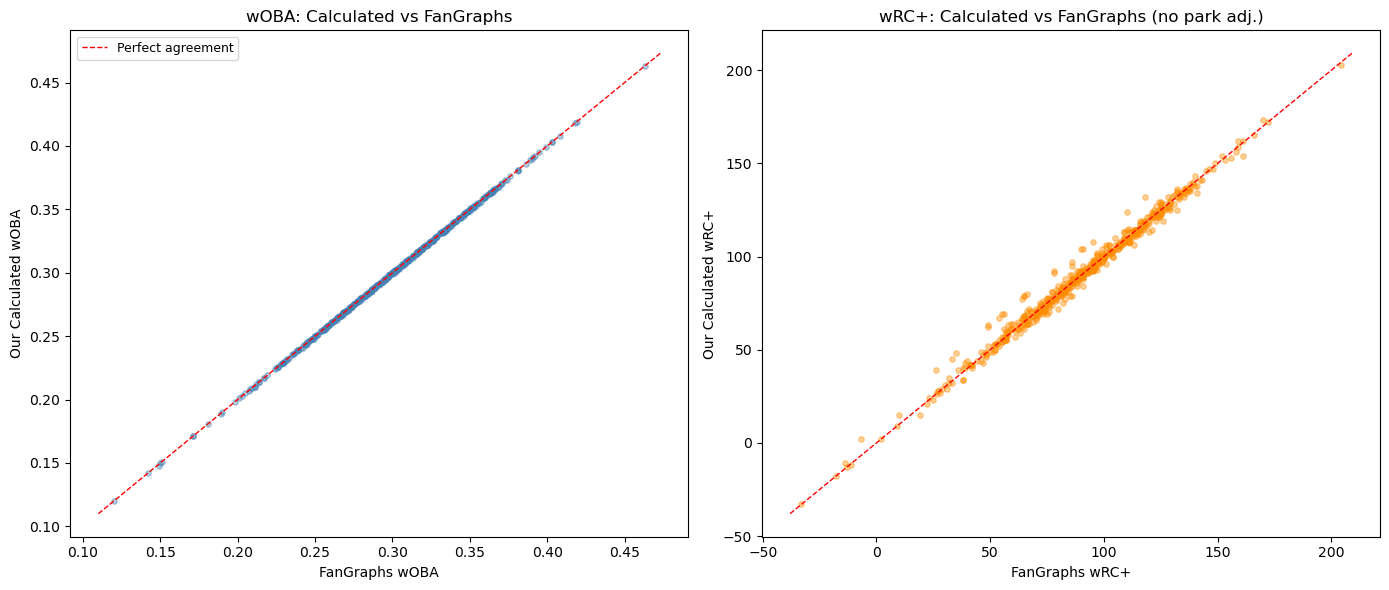

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel 1: wOBA scatter
ax = axes[0]
ax.scatter(compare["fg_wOBA"], compare["calc_wOBA"], alpha=0.4, s=15, c="steelblue")
lims = [compare["fg_wOBA"].min() - 0.01, compare["fg_wOBA"].max() + 0.01]
ax.plot(lims, lims, "r--", linewidth=1, label="Perfect agreement")
ax.set_xlabel("FanGraphs wOBA")
ax.set_ylabel("Our Calculated wOBA")
ax.set_title("wOBA: Calculated vs FanGraphs")
ax.legend(fontsize=9)

# Panel 2: wRC+ scatter
ax = axes[1]
ax.scatter(compare["fg_wRC_plus"], compare["calc_wRC_plus"], alpha=0.4, s=15, c="darkorange")
lims_wrc = [compare["fg_wRC_plus"].min() - 5, compare["fg_wRC_plus"].max() + 5]
ax.plot(lims_wrc, lims_wrc, "r--", linewidth=1, label="Perfect agreement")
ax.set_xlabel("FanGraphs wRC+")
ax.set_ylabel("Our Calculated wRC+")
ax.set_title("wRC+: Calculated vs FanGraphs (no park adj.)")

plt.tight_layout()
plt.show()

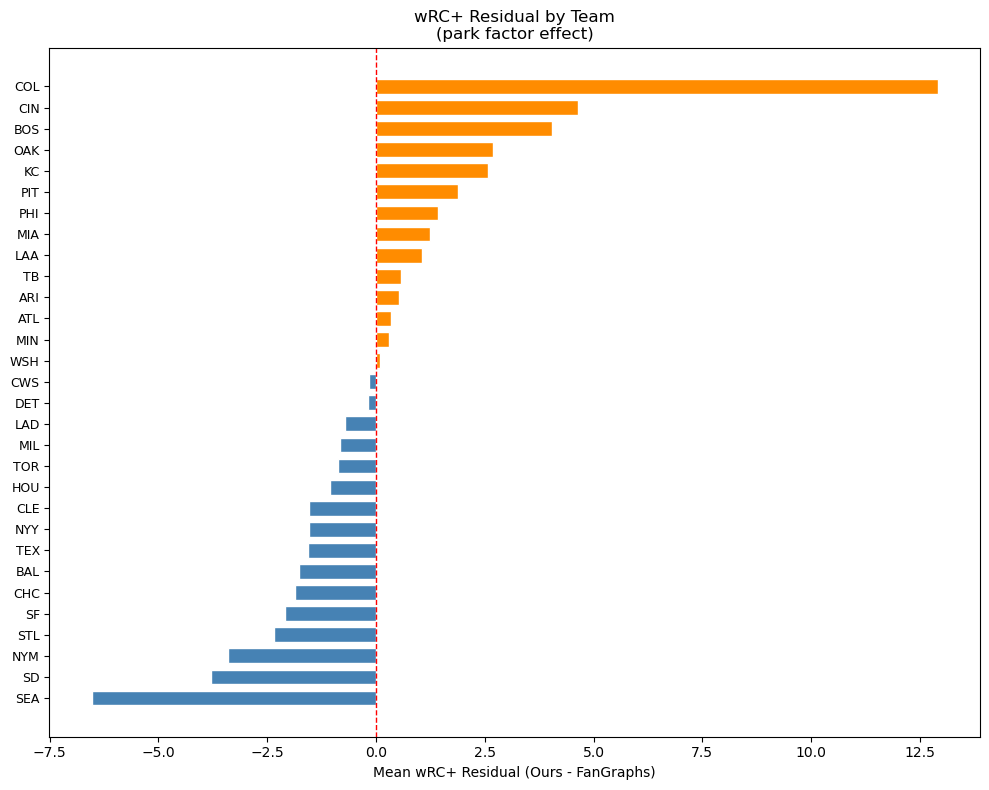

In [40]:
# Create team abbreviation mapping
abbrevs = {
    "Arizona Diamondbacks": "ARI", "Atlanta Braves": "ATL", "Baltimore Orioles": "BAL",
    "Boston Red Sox": "BOS", "Chicago Cubs": "CHC", "Chicago White Sox": "CWS",
    "Cincinnati Reds": "CIN", "Cleveland Guardians": "CLE", "Colorado Rockies": "COL",
    "Detroit Tigers": "DET", "Houston Astros": "HOU", "Kansas City Royals": "KC",
    "Los Angeles Angels": "LAA", "Los Angeles Dodgers": "LAD", "Miami Marlins": "MIA",
    "Milwaukee Brewers": "MIL", "Minnesota Twins": "MIN", "New York Mets": "NYM",
    "New York Yankees": "NYY", "Oakland Athletics": "OAK", "Philadelphia Phillies": "PHI",
    "Pittsburgh Pirates": "PIT", "San Diego Padres": "SD", "San Francisco Giants": "SF",
    "Seattle Mariners": "SEA", "St. Louis Cardinals": "STL", "Tampa Bay Rays": "TB",
    "Texas Rangers": "TEX", "Toronto Blue Jays": "TOR", "Washington Nationals": "WSH",
    "Athletics": "OAK",
}

fig, ax = plt.subplots(1, 1, figsize=(10, 8))

compare_team = compare.merge(hitters[["mlbam_id", "team"]], on="mlbam_id", how="left")
team_bias = compare_team.groupby("team")["wRC_plus_diff"].mean().sort_values()
labels = [abbrevs.get(t, t) for t in team_bias.index]
colors = ["steelblue" if v < 0 else "darkorange" for v in team_bias.values]

ax.barh(range(len(team_bias)), team_bias.values, color=colors, edgecolor="white", height=0.7)
ax.set_yticks(range(len(team_bias)))
ax.set_yticklabels(labels, fontsize=9)
ax.axvline(0, color="red", linestyle="--", linewidth=1)
ax.set_xlabel("Mean wRC+ Residual (Ours - FanGraphs)")
ax.set_title("wRC+ Residual by Team\n(park factor effect)")

plt.tight_layout()
plt.show()